In [2]:
from tensorflow import keras
(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]


print("training images",x_train.shape)
print("y trainuing images",y_train.shape)
print("x_tessting images",y_test.shape)
print("y_testing images",y_test.shape)


training images (60000, 28, 28)
y trainuing images (60000,)
x_tessting images (10000,)
y_testing images (10000,)


In [5]:
#normalise the image
x_train=x_train/255.0
x_test=x_test/255.0
print("x train pixes range",x_train.min() , x_train.max())
print("x testing images pixel rangge",x_test.min() , x_test.max())


x train pixes range 0.0 1.0
x testing images pixel rangge 0.0 1.0


In [8]:
import numpy as np
product_ids=np.arange(len(x_train))
print("total products:",len(product_ids))
print("first 10 product numbers",product_ids[:10])
product_lables=y_train


print("product 0",class_names[product_lables[0]])
print("product 1",class_names[product_lables[1]])
print("product 2",class_names[product_lables[2]])
print("product 3",class_names[product_lables[3]])


total products: 60000
first 10 product numbers [0 1 2 3 4 5 6 7 8 9]
product 0 Ankle Boot
product 1 T-shirt
product 2 T-shirt
product 3 Dress


In [16]:
from tensorflow import keras
features=keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    keras.layers.Conv2D(32,(3,3),activation="relu"),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64,(3,3),activation="relu"),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation="relu")

])
features.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,744 (874.00 KB)

 Trainable params: 223,744 (874.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#compling the model
features.compile(optimizer="adam",loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
#train the model
model=features.fit(x_train,y_train,epochs=10,validation_split=0.2,batch_size=64)





Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.0993 - loss: 4.8520 - val_accuracy: 0.1030 - val_loss: 4.8520
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.0993 - loss: 4.8520 - val_accuracy: 0.1030 - val_loss: 4.8520
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.0993 - loss: 4.8520 - val_accuracy: 0.1030 - val_loss: 4.8520
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.0993 - loss: 4.8520 - val_accuracy: 0.1030 - val_loss: 4.8520
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.0993 - loss: 4.8520 - val_accuracy: 0.1030 - val_loss: 4.8520
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.0993 - loss: 4.8520 - val_accuracy: 0.1030 - val_loss: 4.8520
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.0993 - loss: 4.8520 - val_accuracy: 0.1030 - val_loss: 4.8520
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.0993 - loss: 4.8520 - 

In [25]:
#creat a feature extractor
feature_extractor = keras.Model(#here the MOdel sayes keras build me a model that start at this input and end at this output
    inputs=features.inputs,
    outputs=features.layers[-2].output
)
feature_extractor.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:

#extract features fro product features
product_features=feature_extractor.predict(
    x_train,batch_size=64,verbose=1
)
print("Feature shape:", product_features.shape)


938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step
Feature shape: (60000, 1600)


In [37]:
# Create the product labels
product_labels = y_train

print("Product labels:", product_labels.shape)

Product labels: (60000,)


In [38]:
#save or store the embeddings we got
import numpy as np

# Save
np.save("product_features.npy", product_features)
np.save("product_ids.npy", product_ids)
np.save("product_labels.npy", product_labels)

print("Saved successfully!")

# Load
loaded_features = np.load("product_features.npy")
loaded_ids = np.load("product_ids.npy")
loaded_labels = np.load("product_labels.npy")

print("Features:", loaded_features.shape)
print("IDs:", loaded_ids.shape)
print("Labels:", loaded_labels.shape)

Saved successfully!
Features: (60000, 1600)
IDs: (60000,)
Labels: (60000,)


Query index: 100


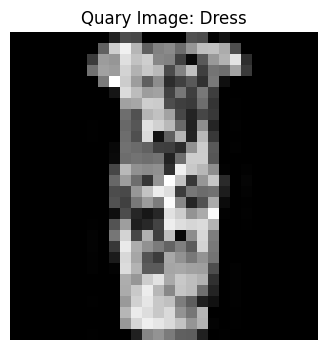

In [41]:
#now giving image so that it could find from the datbase alsp called quary image
quary_index=100#the image number
quary_image=x_test[quary_index]
quary_label = y_test[quary_index]
print("Query index:", quary_index)
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))

plt.imshow(quary_image.squeeze(), cmap="gray")

plt.title(f"Quary Image: {class_names[quary_label]}")
plt.axis("off")

plt.show()

In [45]:
# Convert the query image into a 128-dimensional embedding

quary_embedding = feature_extractor.predict(
    np.expand_dims(quary_image, axis=0),
    verbose=0
)

print("Query embedding shape:", quary_embedding.shape)

Query embedding shape: (1, 1600)


In [46]:
#cosine similarties how similar is the quary vector to each product vector
from sklearn.metrics.pairwise import cosine_similarity
similarities=cosine_similarity(quary_embedding,product_features)[0]

In [47]:
#rank the results
rank=np.argsort(similarities)[::-1]
print("Top 10 ranked")
print(rank[:10])

Top 10 ranked
[55863 59727 59182 48195 26430 16464 27374  2347  9001 35498]


In [48]:
#top k products
top_k = 5

top_indices = rank[:top_k]
top_scores = similarities[top_indices]

print("Top products:")
for product_id, score in zip(top_indices, top_scores):
    print(
        "Product ID:", product_id,
        "| Similarity:", round(float(score), 4)
    )

Top products:
Product ID: 55863 | Similarity: 0.98
Product ID: 59727 | Similarity: 0.98
Product ID: 59182 | Similarity: 0.9792
Product ID: 48195 | Similarity: 0.9791
Product ID: 26430 | Similarity: 0.9778


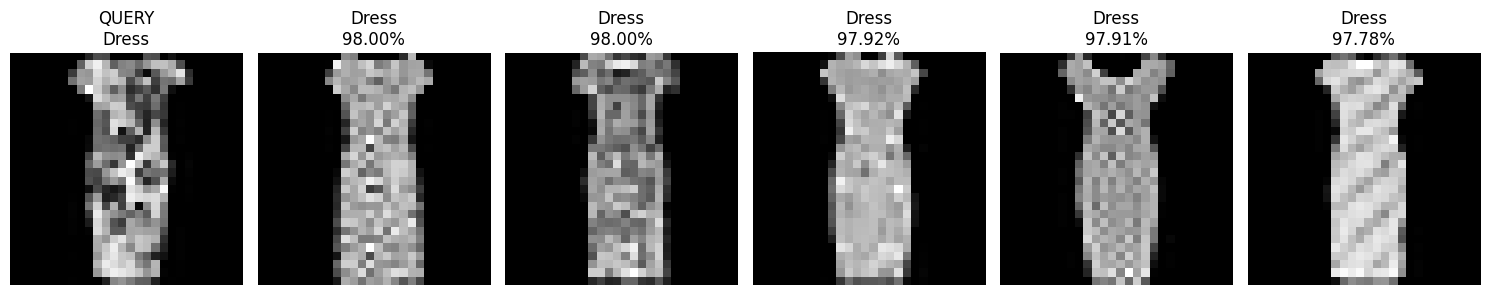

In [50]:
plt.figure(figsize=(15, 4))

# Show query image
plt.subplot(1, top_k + 1, 1)

plt.imshow(
    quary_image.squeeze(),
    cmap="gray"
)

plt.title(
    f"QUERY\n{class_names[quary_label]}"
)

plt.axis("off")


# Show top-K results
for i, product_id in enumerate(top_indices):

    plt.subplot(1, top_k + 1, i + 2)

    plt.imshow(
        x_train[product_id].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"{class_names[product_labels[product_id]]}\n"
        f"{top_scores[i]:.2%}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()